In [ ]:
!pip install -q -U transformers accelerate bitsandbytes peft trl datasets sentencepiece
!pip install -q -U rouge-score bert-score evaluate pynvml sqlglot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 78.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 863.2/863.2 kB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 14.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 707.6/707.6 kB 30.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ibis-framework 9.5.0 requires sqlglot<25.21,>=23.4, but you have sqlglot 30.12.0 which is incompatible.


In [ ]:
!pip uninstall transformers trl -y

!pip install transformers==4.57.1
!pip install trl==0.18.1

Found existing installation: transformers 5.14.1
Uninstalling transformers-5.14.1:
  Successfully uninstalled transformers-5.14.1
Found existing installation: trl 1.8.0
Uninstalling trl-1.8.0:
  Successfully uninstalled trl-1.8.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 116.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 51.6 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.23.0
    Uninstalling huggingface_hub-1.23.0:
      Successfully uninstalled huggingface_hub-1.23.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.3/36

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

print(os.listdir("/content/drive/MyDrive"))
print(os.listdir("/content/drive/MyDrive/slm-text2sql-lora"))
print(os.listdir("/content/drive/MyDrive/slm-text2sql-lora/checkpoint-372"))

Mounted at /content/drive
['Colab Notebooks', 'slm-text2sql-lora', 'token_efficiency_eval_results.csv']
['checkpoint-275', 'checkpoint-300', 'checkpoint-325', 'checkpoint-350', 'checkpoint-372', 'README.md', 'adapter_model.safetensors', 'adapter_config.json', 'chat_template.jinja', 'tokenizer_config.json', 'added_tokens.json', 'tokenizer.model', 'tokenizer.json', 'training_args.bin', 'special_tokens_map.json']
['README.md', 'adapter_model.safetensors', 'adapter_config.json', 'chat_template.jinja', 'tokenizer_config.json', 'special_tokens_map.json', 'added_tokens.json', 'tokenizer.model', 'tokenizer.json', 'training_args.bin', 'optimizer.pt', 'scheduler.pt', 'rng_state.pth', 'trainer_state.json']


In [ ]:

# 2. Authenticate with Hugging Face (token entered privately, never hardcoded/echoed)
from getpass import getpass
from huggingface_hub import login
hf_token = getpass("Paste your Hugging Face token (input hidden): ")
login(hf_token)
del hf_token  # don't keep it lying around in a variable longer than needed


Paste your Hugging Face token (input hidden): ··········


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

# 3. Central config — tweak these to run different experiments
import torch

CONFIG = {
    # Model: swap for any causal LM small enough for your Colab GPU
    "model_id": "google/gemma-3-4b-it",

    # Primary dataset (official BIRD-bench HF release). If you have access to the
    # ~9.4k "OpenAI chat format with schema+hints" mirror you mentioned, put its
    # repo id here instead — the loader below adapts to either schema.
    "dataset_id": "birdsql/bird23-train-filtered",
    "dataset_fallback_ids": ["birdsql/bird_mini_dev"],

    "max_seq_len": 1024,
    "eval_sample_size": 150,
    "seed": 42,

    # LoRA (QLoRA-style, per 2502.13313 findings)
    "lora_r": 16,
    "lora_alpha": 32,
    "lora_dropout": 0.05,
    "lora_target_modules": ["q_proj", "k_proj", "v_proj", "o_proj"],

    # Semantic-aware-layer-freezing-inspired knob: freeze the bottom N% of decoder
    # layers. Set to 0.0 to disable (train all LoRA-adapted layers).
    "freeze_bottom_fraction": 0.5,

    # Training
    "num_train_epochs": 1,
    "per_device_train_batch_size": 4,
    "gradient_accumulation_steps": 4,
    "learning_rate": 2e-4,
    # "output_dir": "./slm-text2sql-lora",
    "output_dir": "/content/drive/MyDrive/slm-text2sql-lora",

    # Token-optimization strategies to compare at eval time
    "prompt_strategies": ["full_schema", "linked_schema", "minimal"],
    "max_new_tokens": 128,

    # Cost/energy assumptions (edit to match your actual GPU / cloud pricing)
    "gpu_tdp_watts": 70.0,        # e.g. T4 ~70W, A100 ~250-400W under load
    "usd_per_kwh": 0.15,
    "usd_per_gpu_hour": 0.35,     # rough Colab Pro-style reference; adjust for your setup
}

torch.manual_seed(CONFIG["seed"])
print(CONFIG)


{'model_id': 'google/gemma-3-4b-it', 'dataset_id': 'birdsql/bird23-train-filtered', 'dataset_fallback_ids': ['birdsql/bird_mini_dev'], 'max_seq_len': 1024, 'eval_sample_size': 150, 'seed': 42, 'lora_r': 16, 'lora_alpha': 32, 'lora_dropout': 0.05, 'lora_target_modules': ['q_proj', 'k_proj', 'v_proj', 'o_proj'], 'freeze_bottom_fraction': 0.5, 'num_train_epochs': 1, 'per_device_train_batch_size': 4, 'gradient_accumulation_steps': 4, 'learning_rate': 0.0002, 'output_dir': '/content/drive/MyDrive/slm-text2sql-lora', 'prompt_strategies': ['full_schema', 'linked_schema', 'minimal'], 'max_new_tokens': 128, 'gpu_tdp_watts': 70.0, 'usd_per_kwh': 0.15, 'usd_per_gpu_hour': 0.35}


In [ ]:

# 4. Load BIRD data, normalizing whichever column names the mirror uses
from datasets import load_dataset, Dataset

def try_load(dataset_id):
    try:
        ds = load_dataset(dataset_id)
        print(f"Loaded '{dataset_id}' -> splits: {list(ds.keys())}")
        return ds
    except Exception as e:
        print(f"Could not load '{dataset_id}': {e}")
        return None

raw = try_load(CONFIG["dataset_id"])
if raw is None:
    for alt in CONFIG["dataset_fallback_ids"]:
        raw = try_load(alt)
        if raw is not None:
            break
if raw is None:
    raise RuntimeError(
        "No dataset could be loaded. Paste the exact HF dataset repo id you have "
        "access to into CONFIG['dataset_id'] and rerun this cell."
    )

split_name = "train" if "train" in raw else list(raw.keys())[0]
data = raw[split_name]
print(data)
print(data[0])


README.md:   0%|          | 0.00/4.42k [00:00<?, ?B/s]

train-00000-of-00001.jsonl:   0%|          | 0.00/2.65M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6601 [00:00<?, ? examples/s]

Loaded 'birdsql/bird23-train-filtered' -> splits: ['train']
Dataset({
    features: ['db_id', 'question', 'evidence', 'SQL'],
    num_rows: 6601
})
{'db_id': 'movie_platform', 'question': 'Who is the director of the movie Sex, Drink and Bloodshed?', 'evidence': "Sex, Drink and Bloodshed refers to movie title = 'Sex, Drink and Bloodshed';", 'SQL': "SELECT director_name FROM movies WHERE movie_title = 'Sex, Drink and Bloodshed'"}


In [ ]:

# 5. Normalize field names across possible BIRD/HF mirror schemas.
# BIRD-style examples typically carry some subset of: question, evidence/hint,
# db_id, schema/context (DDL or table/column list), SQL/query (gold answer).


def get_field(example, candidates, default=""):
    for c in candidates:
        if c in example and example[c]:
            return example[c]
    return default

def normalize(example):
    return {
        "question": get_field(example, ["question", "instruction", "nl_question"]),
        "hint": get_field(example, ["evidence", "hint", "external_knowledge"]),
        "schema": get_field(example, ["schema", "context", "db_schema", "table_info", "ddl"]),
        "db_id": get_field(example, ["db_id", "database", "db"]),
        "sql": get_field(example, ["SQL", "sql", "query", "gold_sql", "answer"]),
    }

normalized = [normalize(ex) for ex in data]
print(f"Total examples: {len(normalized)}")
print(normalized[0])

missing_schema = sum(1 for r in normalized if not r["schema"])
missing_sql = sum(1 for r in normalized if not r["sql"])
print(f"Examples missing schema text: {missing_schema} | missing SQL: {missing_sql}")
if missing_schema > len(normalized) * 0.5:
    print("WARNING: most rows have no inline schema string — this mirror may store "
          "schema in a separate DB file/table rather than as text. You'll need to "
          "materialize schema strings yourself (e.g. from the BIRD sqlite DBs) before "
          "the 'full_schema'/'linked_schema' strategies below will be meaningful.")


Total examples: 6601
{'question': 'Who is the director of the movie Sex, Drink and Bloodshed?', 'hint': "Sex, Drink and Bloodshed refers to movie title = 'Sex, Drink and Bloodshed';", 'schema': '', 'db_id': 'movie_platform', 'sql': "SELECT director_name FROM movies WHERE movie_title = 'Sex, Drink and Bloodshed'"}
Examples missing schema text: 6601 | missing SQL: 0


In [ ]:

# 6. Build prompts under three token-optimization strategies.
# full_schema   -> baseline: dump entire schema + hint verbatim (most tokens)
# linked_schema -> crude schema-linking: keep only tables/columns whose names
#                  share a token with the question (fewer tokens, same info need)
# minimal       -> terse instruction, hint dropped, schema linked (fewest tokens)

import re

def parse_schema_units(schema_text):

    if not schema_text:
        return []
    chunks = re.split(r"(?=CREATE TABLE)", schema_text, flags=re.IGNORECASE)
    chunks = [c.strip() for c in chunks if c.strip()]
    return chunks if chunks else [schema_text]

def link_schema(question, schema_text, hint=""):
    chunks = parse_schema_units(schema_text)
    if len(chunks) <= 1:
        return schema_text  # nothing to filter
    q_tokens = set(re.findall(r"[a-zA-Z_]+", (question + " " + hint).lower()))
    kept = []
    for chunk in chunks:
        chunk_tokens = set(re.findall(r"[a-zA-Z_]+", chunk.lower()))
        if q_tokens & chunk_tokens:
            kept.append(chunk)
    return "\n".join(kept) if kept else "\n".join(chunks[:1])

SYSTEM_FULL = "You are a text-to-SQL assistant. Given a database schema, a question, and an optional hint, write the correct SQLite query. Return only the SQL query."
SYSTEM_MINIMAL = "Write the SQLite query for the question using the schema. SQL only."

def build_prompt(row, strategy):
    if strategy == "full_schema":
        system = SYSTEM_FULL
        user = f"Schema:\n{row['schema']}\n\nHint: {row['hint']}\n\nQuestion: {row['question']}"
    elif strategy == "linked_schema":
        system = SYSTEM_FULL
        linked = link_schema(row["question"], row["schema"], row["hint"])
        user = f"Schema:\n{linked}\n\nHint: {row['hint']}\n\nQuestion: {row['question']}"
    elif strategy == "minimal":
        system = SYSTEM_MINIMAL
        linked = link_schema(row["question"], row["schema"], row["hint"])
        user = f"Schema:\n{linked}\n\nQ: {row['question']}"
    else:
        raise ValueError(strategy)
    return system, user

print(build_prompt(normalized[0], "full_schema"))
print("---")
print(build_prompt(normalized[0], "linked_schema"))


('You are a text-to-SQL assistant. Given a database schema, a question, and an optional hint, write the correct SQLite query. Return only the SQL query.', "Schema:\n\n\nHint: Sex, Drink and Bloodshed refers to movie title = 'Sex, Drink and Bloodshed';\n\nQuestion: Who is the director of the movie Sex, Drink and Bloodshed?")
---
('You are a text-to-SQL assistant. Given a database schema, a question, and an optional hint, write the correct SQLite query. Return only the SQL query.', "Schema:\n\n\nHint: Sex, Drink and Bloodshed refers to movie title = 'Sex, Drink and Bloodshed';\n\nQuestion: Who is the director of the movie Sex, Drink and Bloodshed?")


In [ ]:

# 7. Load tokenizer + 4-bit quantized base model
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_id"])
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)

model = AutoModelForCausalLM.from_pretrained(
    CONFIG["model_id"],
    quantization_config=bnb_config,
    device_map="auto",
)
model.config.use_cache = False
print(model.config)


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/4.69M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

...

model-00002-of-00002.safetensors:   0%|          | 0.00/3.64G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.96G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

Gemma3Config {
  "architectures": [
    "Gemma3ForConditionalGeneration"
  ],
  "boi_token_index": 255999,
  "dtype": "float16",
  "eoi_token_index": 256000,
  "eos_token_id": [
    1,
    106
  ],
  "image_token_index": 262144,
  "initializer_range": 0.02,
  "mm_tokens_per_image": 256,
  "model_type": "gemma3",
  "quantization_config": {
    "_load_in_4bit": true,
    "_load_in_8bit": false,
    "bnb_4bit_compute_dtype": "float16",
    "bnb_4bit_quant_storage": "uint8",
    "bnb_4bit_quant_type": "nf4",
    "bnb_4bit_use_double_quant": false,
    "llm_int8_enable_fp32_cpu_offload": false,
    "llm_int8_has_fp16_weight": false,
    "llm_int8_skip_modules": null,
    "llm_int8_threshold": 6.0,
    "load_in_4bit": true,
    "load_in_8bit": false,
    "quant_method": "bitsandbytes"
  },
  "text_config": {
    "_sliding_window_pattern": 6,
    "attention_bias": false,
    "attention_dropout": 0.0,
    "attn_logit_softcapping": null,
    "dtype": "float16",
    "final_logit_softcapping": nu

In [ ]:

# 8. Quantify prompt-token savings per strategy BEFORE we even train —
# this is the headline "token efficiency" number the objective asks for.
import statistics as stats

def prompt_token_len(system, user):
    text = tokenizer.apply_chat_template(
        [{"role": "system", "content": system}, {"role": "user", "content": user}],
        tokenize=False, add_generation_prompt=True,
    )
    return len(tokenizer(text, add_special_tokens=False)["input_ids"])

sample_for_counts = normalized[: min(300, len(normalized))]
for strategy in CONFIG["prompt_strategies"]:
    lens = [prompt_token_len(*build_prompt(r, strategy)) for r in sample_for_counts]
    print(f"{strategy:14s} avg_prompt_tokens={stats.mean(lens):.1f}  "
          f"median={stats.median(lens):.1f}  max={max(lens)}")


full_schema    avg_prompt_tokens=96.2  median=90.0  max=176
linked_schema  avg_prompt_tokens=96.2  median=90.0  max=176
minimal        avg_prompt_tokens=46.9  median=45.0  max=78


In [ ]:

# 9. Assemble the supervised fine-tuning dataset.
# We train on ONE strategy at a time (default: linked_schema, a middle ground) so the
# model learns to answer from compact prompts; you can rerun this cell + the train cell
# per strategy if you want strategy-specific fine-tunes rather than one model evaluated
# zero-shot-ish across prompt styles.

TRAIN_STRATEGY = "linked_schema"

def to_chat_example(row):
    system, user = build_prompt(row, TRAIN_STRATEGY)
    messages = [
        {"role": "system", "content": system},
        {"role": "user", "content": user},
        {"role": "assistant", "content": row["sql"].strip()},
    ]
    text = tokenizer.apply_chat_template(messages, tokenize=False)
    return {"text": text}

usable = [r for r in normalized if r["sql"] and r["question"]]
split_idx = int(len(usable) * 0.9)
train_rows, test_rows = usable[:split_idx], usable[split_idx:]

train_ds = Dataset.from_list([to_chat_example(r) for r in train_rows])
print(f"Train examples: {len(train_ds)} | held-out test examples: {len(test_rows)}")
print(train_ds[0]["text"][:500])


Train examples: 5940 | held-out test examples: 661
<bos><start_of_turn>user
You are a text-to-SQL assistant. Given a database schema, a question, and an optional hint, write the correct SQLite query. Return only the SQL query.

Schema:


Hint: Sex, Drink and Bloodshed refers to movie title = 'Sex, Drink and Bloodshed';

Question: Who is the director of the movie Sex, Drink and Bloodshed?<end_of_turn>
<start_of_turn>model
SELECT director_name FROM movies WHERE movie_title = 'Sex, Drink and Bloodshed'<end_of_turn>



In [ ]:
# 10. Apply LoRA, then optionally freeze the bottom fraction of decoder layers
# (a simplified, config-driven stand-in for the SALF per-layer gain estimator —
# real SALF computes per-layer deviation/gain from a scaling law; here we just
# freeze a fixed bottom fraction as a cheap approximation.)

from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training,
    PeftModel,
)

model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=CONFIG["lora_r"],
    lora_alpha=CONFIG["lora_alpha"],
    lora_dropout=CONFIG["lora_dropout"],
    target_modules=CONFIG["lora_target_modules"],
    bias="none",
    task_type="CAUSAL_LM",
)

model = get_peft_model(model, lora_config)


def freeze_bottom_layers(model, fraction):
    if fraction <= 0:
        return 0

    # -------------------------------------------------------------
    # Unwrap nested PEFT/LoRA wrappers until we reach the HF model
    # -------------------------------------------------------------
    base = model
    while isinstance(base, PeftModel):
        base = base.get_base_model().model

    print(f"Underlying model: {base.__class__.__name__}")

    # -------------------------------------------------------------
    # Locate decoder layers
    # -------------------------------------------------------------

    layers = None

    candidate_paths = [
        "language_model.layers",        # Gemma3Model (new Transformers)
        "model.language_model.layers",  # Gemma3ForConditionalGeneration (older)
        "model.layers",                 # Llama / Mistral / Qwen
        "transformer.h",                # GPT-2
    ]

    for path in candidate_paths:
        obj = base
        try:
            for attr in path.split("."):
                obj = getattr(obj, attr)
            layers = obj
            print(f"Found decoder layers: {path}")
            break
        except AttributeError:
            continue

    if layers is None:
        print("❌ Could not locate decoder layers.")
        return 0

    # -------------------------------------------------------------
    # Freeze bottom fraction
    # -------------------------------------------------------------
    n_layers = len(layers)
    n_freeze = int(n_layers * fraction)

    for layer in layers[:n_freeze]:
        for p in layer.parameters():
            p.requires_grad = False

    print(f"✓ Froze {n_freeze}/{n_layers} decoder layers.")

    return n_freeze


freeze_bottom_layers(model, CONFIG["freeze_bottom_fraction"])

model.print_trainable_parameters()

Underlying model: Gemma3Model
Found decoder layers: language_model.layers
✓ Froze 17/34 decoder layers.
trainable params: 7,442,432 || all params: 4,311,978,352 || trainable%: 0.1726


In [ ]:
from trl import SFTTrainer, SFTConfig

sft_config = SFTConfig(
    output_dir=CONFIG["output_dir"],
    num_train_epochs=CONFIG["num_train_epochs"],
    per_device_train_batch_size=CONFIG["per_device_train_batch_size"],
    gradient_accumulation_steps=CONFIG["gradient_accumulation_steps"],
    learning_rate=CONFIG["learning_rate"],

    logging_steps=10,

    # Save checkpoints regularly
    save_strategy="steps",
    save_steps=25,          # saves every 50 training steps
    save_total_limit=5,     # keeps only latest 3 checkpoints

    bf16=torch.cuda.is_bf16_supported(),
    fp16=not torch.cuda.is_bf16_supported(),

    dataset_text_field="text",
    report_to=[],
)

trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=train_ds,
    processing_class=tokenizer,
)

trainer.train()

# Final save after training completes
trainer.save_model(CONFIG["output_dir"])
tokenizer.save_pretrained(CONFIG["output_dir"])

Converting train dataset to ChatML:   0%|          | 0/5940 [00:00<?, ? examples/s]

Adding EOS to train dataset:   0%|          | 0/5940 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/5940 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/5940 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 1, 'bos_token_id': 2, 'pad_token_id': 0}.
`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss
10,3.017200
20,1.344900
30,1.019100
40,0.957200
50,0.871400
60,0.833700
70,0.827800
80,0.827500
90,0.782200
100,0.747400


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt

('/content/drive/MyDrive/slm-text2sql-lora/tokenizer_config.json',
 '/content/drive/MyDrive/slm-text2sql-lora/special_tokens_map.json',
 '/content/drive/MyDrive/slm-text2sql-lora/chat_template.jinja',
 '/content/drive/MyDrive/slm-text2sql-lora/tokenizer.model',
 '/content/drive/MyDrive/slm-text2sql-lora/added_tokens.json',
 '/content/drive/MyDrive/slm-text2sql-lora/tokenizer.json')

Phase 2 - using new weights

In [ ]:
import torch
import transformers
import peft

print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("Torch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("PEFT:", peft.__version__)

try:
    import torchao
    print("TorchAO:", torchao.__version__)
except Exception as e:
    print("TorchAO:", e)

CUDA: True
GPU: Tesla T4
Torch: 2.11.0+cu128
Transformers: 5.13.1
PEFT: 0.19.1
TorchAO: 0.10.0


In [ ]:
!pip uninstall -y torchao

Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0


In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel
import torch

BASE_MODEL = "google/gemma-3-4b-it"
LORA_PATH = "/content/drive/MyDrive/slm-text2sql-lora"

tokenizer = AutoTokenizer.from_pretrained(LORA_PATH)

base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    torch_dtype=torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16,
    device_map="auto",
)

model = PeftModel.from_pretrained(
    base_model,
    LORA_PATH,
)

model.eval()

config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json:   0%|          | 0.00/90.6k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/peft/peft_model.py:622: UserWarning: Found missing adapter keys while loading the checkpoint: ['base_model.model.model.vision_tower.encoder.layers.0.self_attn.k_proj.lora_A.default.weight', 'base_model.model.model.vision_tower.encoder.layers.0.self_attn.k_proj.lora_B.default.weight', 'base_model.model.model.vision_tower.encoder.layers.0.self_attn.v_proj.lora_A.default.weight', 'base_model.model.model.vision_tower.encoder.layers.0.self_attn.v_proj.lora_B.default.weight', 'base_model.model.model.vision_tower.encoder.layers.0.self_attn.q_proj.lora_A.default.weight', 'base_model.model.model.vision_tower.encoder.layers.0.self_attn.q_proj.lora_B.default.weight', 'base_model.model.model.vision_tower.encoder.layers.1.self_attn.k_proj.lora_A.default.weight', 'base_model.model.model.vision_tower.encoder.layers.1.self_attn.k_proj.lora_B.default.weight', 'base_model.model.model.vision_tower.encoder.layers.1.self_attn.v_proj.lora_A.default.weight', 'base_mode

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Gemma3ForConditionalGeneration(
      (model): Gemma3Model(
        (vision_tower): SiglipVisionModel(
          (embeddings): SiglipVisionEmbeddings(
            (patch_embedding): Conv2d(3, 1152, kernel_size=(14, 14), stride=(14, 14), padding=valid)
            (position_embedding): Embedding(4096, 1152)
          )
          (encoder): SiglipEncoder(
            (layers): ModuleList(
              (0-26): 27 x SiglipEncoderLayer(
                (layer_norm1): LayerNorm((1152,), eps=1e-06, elementwise_affine=True)
                (self_attn): SiglipAttention(
                  (k_proj): lora.Linear(
                    (base_layer): Linear(in_features=1152, out_features=1152, bias=True)
                    (lora_dropout): ModuleDict(
                      (default): Dropout(p=0.05, inplace=False)
                    )
                    (lora_A): ModuleDict(
                      (default): Linear(in_features=1152, out_f

In [ ]:

# 12. GPU power instrumentation
import time
try:
    import pynvml
    pynvml.nvmlInit()
    _handle = pynvml.nvmlDeviceGetHandleByIndex(0)
    def sample_power_watts():
        return pynvml.nvmlDeviceGetPowerUsage(_handle) / 1000.0
    HAVE_NVML = True
except Exception as e:
    print(f"pynvml unavailable ({e}); falling back to CONFIG['gpu_tdp_watts'] as a flat estimate.")
    HAVE_NVML = False
    def sample_power_watts():
        return CONFIG["gpu_tdp_watts"]

def generate_and_measure(system, user, max_new_tokens):
    messages = [{"role": "system", "content": system}, {"role": "user", "content": user}]
    prompt_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt_text, return_tensors="pt").to(model.device)
    prompt_tokens = inputs["input_ids"].shape[1]

    power_samples = [sample_power_watts()]
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    with torch.no_grad():
        out = model.generate(
            **inputs, max_new_tokens=max_new_tokens,
            do_sample=False, pad_token_id=tokenizer.pad_token_id,
        )
    torch.cuda.synchronize()
    t1 = time.perf_counter()
    power_samples.append(sample_power_watts())

    output_tokens = out.shape[1] - prompt_tokens
    latency_s = t1 - t0
    avg_watts = sum(power_samples) / len(power_samples)
    energy_kwh = (avg_watts * latency_s) / 3_600_000.0  # W * s -> kWh
    cost_usd = energy_kwh * CONFIG["usd_per_kwh"]
    gpu_time_cost_usd = (latency_s / 3600.0) * CONFIG["usd_per_gpu_hour"]

    generated_text = tokenizer.decode(out[0][prompt_tokens:], skip_special_tokens=True)
    return {
        "generated_sql": generated_text.strip(),
        "prompt_tokens": prompt_tokens,
        "output_tokens": max(output_tokens, 0),
        "latency_s": latency_s,
        "throughput_tok_s": (output_tokens / latency_s) if latency_s > 0 else 0.0,
        "avg_watts": avg_watts,
        "energy_kwh": energy_kwh,
        "energy_cost_usd": cost_usd,
        "gpu_time_cost_usd": gpu_time_cost_usd,
    }


In [ ]:
!pip install rouge-score evaluate bert-score

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 6.9 MB/s eta 0:00:00
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=3e85a3393cc3c3532ab7763884d35ed5da1dfd14acaa5b1d226623de6f97b936
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score


In [ ]:

# 13. Quality metrics: Exact Match, token-F1, ROUGE-L, BERTScore
from rouge_score import rouge_scorer
import evaluate as hf_evaluate

rouge = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)
bertscore = hf_evaluate.load("bertscore")

def normalize_sql(s):
    return " ".join(s.strip().rstrip(";").lower().split())

def exact_match(pred, gold):
    return float(normalize_sql(pred) == normalize_sql(gold))

def token_f1(pred, gold):
    p_toks, g_toks = normalize_sql(pred).split(), normalize_sql(gold).split()
    if not p_toks or not g_toks:
        return 0.0
    common = {}
    for t in p_toks:
        common[t] = common.get(t, 0) + 1
    overlap = 0
    g_counts = {}
    for t in g_toks:
        g_counts[t] = g_counts.get(t, 0) + 1
    for t, c in common.items():
        overlap += min(c, g_counts.get(t, 0))
    if overlap == 0:
        return 0.0
    precision = overlap / len(p_toks)
    recall = overlap / len(g_toks)
    return 2 * precision * recall / (precision + recall)

def rouge_l(pred, gold):
    return rouge.score(gold, pred)["rougeL"].fmeasure

def bertscore_f1_batch(preds, golds):
    result = bertscore.compute(predictions=preds, references=golds, lang="en")
    return result["f1"]


In [ ]:

# 14. Run the eval sweep across prompt strategies on the held-out test rows
import pandas as pd

eval_rows = test_rows[: CONFIG["eval_sample_size"]]
all_results = []

for strategy in CONFIG["prompt_strategies"]:
    preds, golds = [], []
    for row in eval_rows:
        system, user = build_prompt(row, strategy)
        metrics = generate_and_measure(system, user, CONFIG["max_new_tokens"])
        metrics["strategy"] = strategy
        metrics["gold_sql"] = row["sql"]
        metrics["exact_match"] = exact_match(metrics["generated_sql"], row["sql"])
        metrics["token_f1"] = token_f1(metrics["generated_sql"], row["sql"])
        metrics["rouge_l"] = rouge_l(metrics["generated_sql"], row["sql"])
        preds.append(metrics["generated_sql"])
        golds.append(row["sql"])
        all_results.append(metrics)

    # BERTScore is batched for efficiency; attach after the loop for this strategy
    bs_f1 = bertscore_f1_batch(preds, golds)
    for r, bs in zip(all_results[-len(eval_rows):], bs_f1):
        r["bertscore_f1"] = bs

results_df = pd.DataFrame(all_results)
results_df.to_csv(
    "/content/drive/MyDrive/token_efficiency_eval_results.csv",
    index=False
)
results_df.head()


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.42GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


,generated_sql,prompt_tokens,output_tokens,latency_s,throughput_tok_s,avg_watts,energy_kwh,energy_cost_usd,gpu_time_cost_usd,strategy,gold_sql,exact_match,token_f1,rouge_l,bertscore_f1
0,SELECT CAST(SUM(CASE WHEN T1.gender = 'F' AND ...,106,84,10.903504,7.703945,46.0190,0.000139,0.000021,0.001060,full_schema,SELECT CAST(SUM(CASE WHEN T2.gender = 'F' AND ...,0.0,0.850000,0.837209,0.971631
1,SELECT T1.PATIENT FROM patients AS T1 INNER JO...,151,67,14.671048,4.566818,63.4550,0.000259,0.000039,0.001426,full_schema,"SELECT T1.first, T1.last FROM patients AS T1 I...",0.0,0.800000,0.811594,0.942981
2,SELECT T2.DESCRIPTION FROM patients AS T1 INNE...,86,51,5.533930,9.215874,63.5835,0.000098,0.000015,0.000538,full_schema,SELECT DISTINCT T1.REASONDESCRIPTION FROM care...,0.0,0.765957,0.666667,0.930217
3,"SELECT T1.first, T1.last FROM patients AS T1 I...",114,72,8.271795,8.704278,62.0750,0.000143,0.000021,0.000804,full_schema,"SELECT T2.first, T2.last FROM conditions AS T1...",0.0,0.579710,0.533333,0.912342
4,SELECT DISTINCT T1.SalesAgentID FROM Sales AS ...,78,52,5.717579,9.094758,62.5070,0.000099,0.000015,0.000556,full_schema,"SELECT DISTINCT T3.lastName, T3.firstName FROM...",0.0,0.571429,0.555556,0.910850


In [ ]:
import pandas as pd

results_df = pd.read_csv(
    "/content/drive/MyDrive/token_efficiency_eval_results.csv"
)

print(results_df.shape)
results_df.head()

(450, 15)


,generated_sql,prompt_tokens,output_tokens,latency_s,throughput_tok_s,avg_watts,energy_kwh,energy_cost_usd,gpu_time_cost_usd,strategy,gold_sql,exact_match,token_f1,rouge_l,bertscore_f1
0,SELECT CAST(SUM(CASE WHEN T1.gender = 'F' AND ...,106,84,10.903504,7.703945,46.0190,0.000139,0.000021,0.001060,full_schema,SELECT CAST(SUM(CASE WHEN T2.gender = 'F' AND ...,0.0,0.850000,0.837209,0.971631
1,SELECT T1.PATIENT FROM patients AS T1 INNER JO...,151,67,14.671048,4.566818,63.4550,0.000259,0.000039,0.001426,full_schema,"SELECT T1.first, T1.last FROM patients AS T1 I...",0.0,0.800000,0.811594,0.942981
2,SELECT T2.DESCRIPTION FROM patients AS T1 INNE...,86,51,5.533930,9.215874,63.5835,0.000098,0.000015,0.000538,full_schema,SELECT DISTINCT T1.REASONDESCRIPTION FROM care...,0.0,0.765957,0.666667,0.930217
3,"SELECT T1.first, T1.last FROM patients AS T1 I...",114,72,8.271795,8.704278,62.0750,0.000143,0.000021,0.000804,full_schema,"SELECT T2.first, T2.last FROM conditions AS T1...",0.0,0.579710,0.533333,0.912342
4,SELECT DISTINCT T1.SalesAgentID FROM Sales AS ...,78,52,5.717579,9.094758,62.5070,0.000099,0.000015,0.000556,full_schema,"SELECT DISTINCT T3.lastName, T3.firstName FROM...",0.0,0.571429,0.555556,0.910850


In [ ]:

# 15. Aggregate: quality vs. efficiency per strategy
summary = results_df.groupby("strategy").agg(
    avg_prompt_tokens=("prompt_tokens", "mean"),
    avg_output_tokens=("output_tokens", "mean"),
    avg_latency_s=("latency_s", "mean"),
    avg_throughput_tok_s=("throughput_tok_s", "mean"),
    avg_energy_kwh=("energy_kwh", "mean"),
    avg_energy_cost_usd=("energy_cost_usd", "mean"),
    exact_match=("exact_match", "mean"),
    token_f1=("token_f1", "mean"),
    rouge_l=("rouge_l", "mean"),
    bertscore_f1=("bertscore_f1", "mean"),
).reset_index()

summary["total_tokens"] = summary["avg_prompt_tokens"] + summary["avg_output_tokens"]
print(summary.to_string(index=False))
summary.to_csv(
    "/content/drive/MyDrive/token_efficiency_summary.csv",
    index=False,
)


     strategy  avg_prompt_tokens  avg_output_tokens  avg_latency_s  avg_throughput_tok_s  avg_energy_kwh  avg_energy_cost_usd  exact_match  token_f1  rouge_l  bertscore_f1  total_tokens
  full_schema         105.433333          61.126667       7.031513              8.790351        0.000125             0.000019     0.006667  0.623623 0.626993      0.930245    166.560000
linked_schema         105.433333          61.126667       6.813672              8.973192        0.000123             0.000018     0.006667  0.623623 0.626993      0.930245    166.560000
      minimal          51.240000          58.306667       6.318300              9.221951        0.000113             0.000017     0.000000  0.569255 0.547436      0.911303    109.546667


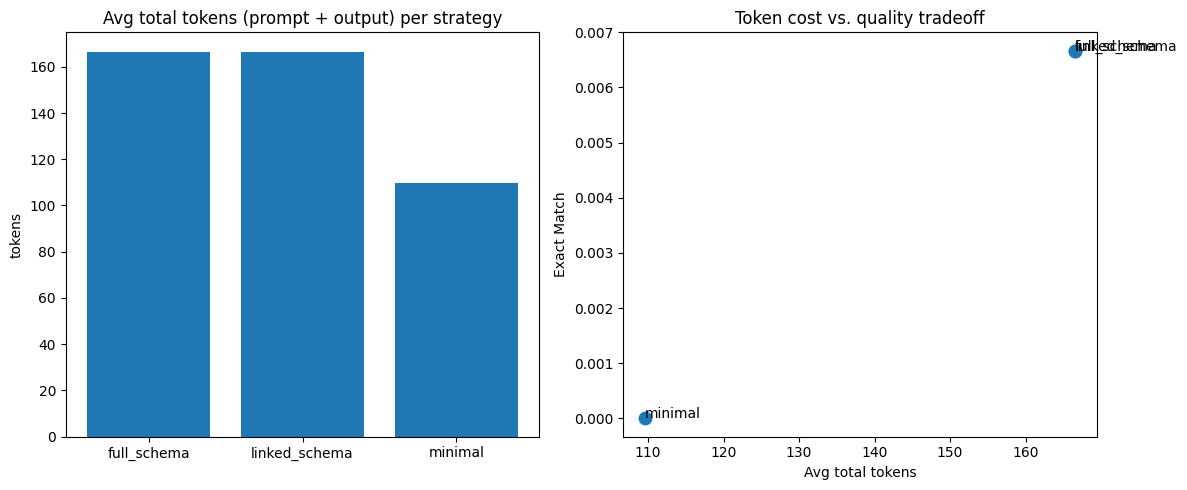

In [ ]:

# 16. Visualize the quality/efficiency tradeoff
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(summary["strategy"], summary["total_tokens"])
axes[0].set_title("Avg total tokens (prompt + output) per strategy")
axes[0].set_ylabel("tokens")

axes[1].scatter(summary["total_tokens"], summary["exact_match"], s=80)
for _, row in summary.iterrows():
    axes[1].annotate(row["strategy"], (row["total_tokens"], row["exact_match"]))
axes[1].set_xlabel("Avg total tokens")
axes[1].set_ylabel("Exact Match")
axes[1].set_title("Token cost vs. quality tradeoff")

plt.tight_layout()
plt.savefig(
    "/content/drive/MyDrive/token_efficiency_tradeoff.png",
    dpi=150,
)
plt.show()
